<a href="https://colab.research.google.com/github/zihxnw/EDGDataVisuals/blob/main/EDG_Data_Vis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
install.packages("jsonlite")
library(jsonlite)
library(dplyr)
library(stringr)
install.packages(c("ggplot2", "scales"))
library(ggplot2)
library(scales)
library(tidyr)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
url <- "https://data.cityofnewyork.us/resource/y6fv-k6p7.json?$limit=50000"
data <- fromJSON(url)
head(data)

,application,organization,total_final_award
,<chr>,<chr>,<chr>
1,FY12-AN-009139,"3 Graces Theater Co., Inc.",5325
2,FY12-RN-009814,3 Legged Dog,15975
3,FY12-RN-009843,"52nd Street Project, Inc.",60750
4,FY12-MY-006965,"7 Loaves, Inc.",18975
5,FY12-RN-009783,"Aaron Davis Hall, Inc.",145625
6,FY12-MY-007865,ABC No Rio,5325


In [ ]:
cleandata <- data %>%
  mutate(total_final_award = as.numeric(total_final_award)) %>%
  mutate(year = str_extract(application, "FY\\d{2}")) %>%
  filter(!is.na(total_final_award))
head(cleandata)


,application,organization,total_final_award,year
,<chr>,<chr>,<dbl>,<chr>
1,FY12-AN-009139,"3 Graces Theater Co., Inc.",5325,FY12
2,FY12-RN-009814,3 Legged Dog,15975,FY12
3,FY12-RN-009843,"52nd Street Project, Inc.",60750,FY12
4,FY12-MY-006965,"7 Loaves, Inc.",18975,FY12
5,FY12-RN-009783,"Aaron Davis Hall, Inc.",145625,FY12
6,FY12-MY-007865,ABC No Rio,5325,FY12


In [ ]:
funding <- cleandata %>%
  group_by(year) %>%
  summarize(
  median = median(total_final_award, na.rm = TRUE),
  total = sum(total_final_award, na.rm = TRUE),
  grant = n()
  ) %>%
  arrange(year)
print(funding)

# A tibble: 14 × 4
   year  median    total grant
   <chr>  <dbl>    <dbl> <int>
 1 FY12   15975 31333234   888
 2 FY13   15500 30867323   885
 3 FY14   15760 32341940   881
 4 FY15   15800 33693202   883
 5 FY16   15000 33964742   918
 6 FY17   16900 37713073   930
 7 FY18   19650 82008700  1874
 8 FY19   20105 44221702   973
 9 FY20   22705 48991884   982
10 FY21   21500 45610381  1031
11 FY22   27950 50338989  1020
12 FY23   32500 58337067  1090
13 FY24   33190 49085432  1031
14 FY25   38320 59361515  1087


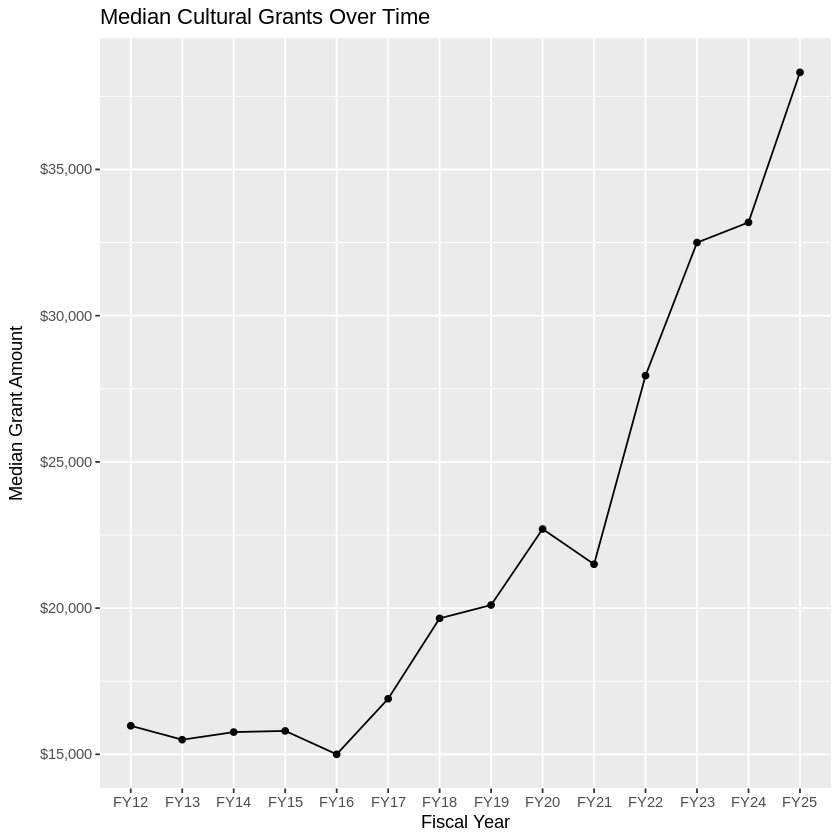

In [ ]:
ggplot(data = funding, aes(x = year, y = median, group = 1)) +
  geom_line() +
  geom_point()+
  scale_y_continuous(labels = scales::dollar) +
labs(
  title = "Median Cultural Grants Over Time",
  x = "Fiscal Year",
  y = "Median Grant Amount"
);

In [ ]:
rentdata <- read.csv("/content/medianAskingRent_All.csv")
head(rentdata)

,areaName,Borough,areaType,X2010.01,X2010.02,X2010.03,X2010.04,X2010.05,X2010.06,X2010.07,⋯,X2025.05,X2025.06,X2025.07,X2025.08,X2025.09,X2025.10,X2025.11,X2025.12,X2026.01,X2026.02
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,All Downtown,Manhattan,submarket,3200,3200,3015,3100,3100,3200,3195,⋯,5250,5307,5450,5410,5350,5345,5350.0,5350.0,5395,5495
2,All Midtown,Manhattan,submarket,2875,2800,2800,2850,2895,2950,3000,⋯,4750,4850,4875,4800,4750,4695,4650.0,4650.0,4717,4875
3,All Upper East Side,Manhattan,submarket,2450,2450,2400,2500,2570,2575,2595,⋯,4150,4200,4200,4200,4195,4125,4227.5,4350.0,4395,4300
4,All Upper Manhattan,Manhattan,submarket,1825,1800,1795,1800,1823,1850,1875,⋯,3195,3245,3300,3230,3208,3195,3125.0,3100.0,3100,3095
5,All Upper West Side,Manhattan,submarket,2895,2800,2750,2800,2800,2795,2800,⋯,4500,4736,4800,4820,4850,4850,4817.0,4942.5,4900,4893
6,Astoria,Queens,neighborhood,1600,1650,1620,1600,1700,1700,1600,⋯,3000,3150,3300,3300,3200,3199,3199.0,3165.0,3195,3150


In [ ]:
nyc_rent <- rentdata %>%
  filter(areaName == "NYC") %>%

  pivot_longer(
    cols = starts_with("X"),
    names_to = "date",
    values_to = "rent"
  ) %>%

  mutate(calendar_year = substr(date, 2, 5)) %>%

  group_by(calendar_year) %>%
  summarize(yearly_rent = mean(rent, na.rm = TRUE)) %>%

  mutate(year = paste0("FY", substr(calendar_year, 3, 4)))

print(nyc_rent)

# A tibble: 17 × 3
   calendar_year yearly_rent year 
   <chr>               <dbl> <chr>
 1 2010                2714. FY10 
 2 2011                2880. FY11 
 3 2012                2988. FY12 
 4 2013                2988. FY13 
 5 2014                2879  FY14 
 6 2015                2862. FY15 
 7 2016                2898. FY16 
 8 2017                2764. FY17 
 9 2018                2736. FY18 
10 2019                2847. FY19 
11 2020                2775. FY20 
12 2021                2626. FY21 
13 2022                3321. FY22 
14 2023                3625  FY23 
15 2024                3678. FY24 
16 2025                3873. FY25 
17 2026                3925  FY26 


In [ ]:
master_data <- funding %>%
  left_join(nyc_rent, by = "year") %>%

  mutate(annual_rent = yearly_rent * 12)

print(master_data)

# A tibble: 14 × 7
   year  median    total grant calendar_year yearly_rent annual_rent
   <chr>  <dbl>    <dbl> <int> <chr>               <dbl>       <dbl>
 1 FY12   15975 31333234   888 2012                2988.      35855 
 2 FY13   15500 30867323   885 2013                2988.      35850 
 3 FY14   15760 32341940   881 2014                2879       34548 
 4 FY15   15800 33693202   883 2015                2862.      34340 
 5 FY16   15000 33964742   918 2016                2898.      34772.
 6 FY17   16900 37713073   930 2017                2764.      33163 
 7 FY18   19650 82008700  1874 2018                2736.      32828.
 8 FY19   20105 44221702   973 2019                2847.      34161 
 9 FY20   22705 48991884   982 2020                2775.      33305 
10 FY21   21500 45610381  1031 2021                2626.      31509 
11 FY22   27950 50338989  1020 2022                3321.      39850.
12 FY23   32500 58337067  1090 2023                3625       43500 
13 FY24   33190

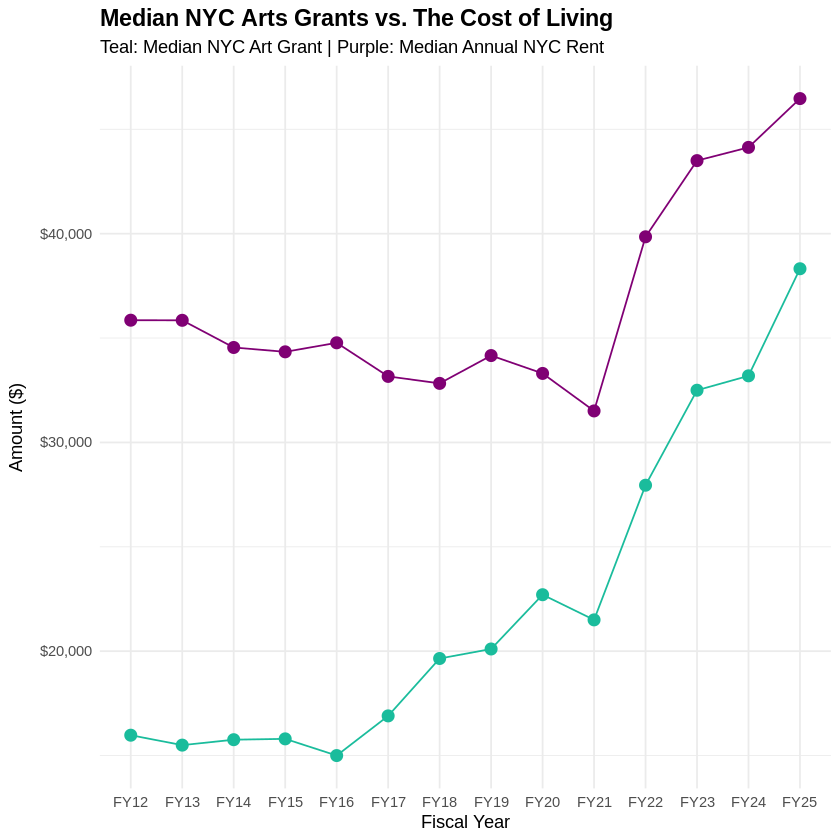

In [ ]:
master_data <- master_data %>%
  mutate(annual_rent = yearly_rent * 12)

ggplot(data = master_data, aes(x = year, group = 1)) +

  geom_line(aes(y = median), color = "#1ABC9C") +
  geom_point(aes(y = median), color = "#1ABC9C", size = 3) +

  geom_line(aes(y = annual_rent), color = "#800074") +
  geom_point(aes(y = annual_rent), color = "#800074", size = 3) +

  scale_y_continuous(labels = scales::dollar) +

  theme_minimal() +

  labs(
    title = "Median NYC Arts Grants vs. The Cost of Living",
    subtitle = "Teal: Median NYC Art Grant | Purple: Median Annual NYC Rent",
    x = "Fiscal Year",
    y = "Amount ($)"
  ) +
  theme(
    plot.title = element_text(face = "bold", size = 14)
  )